In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import stim

circuit = stim.Circuit.generated(
    "surface_code:rotated_memory_z",
    distance=3,
    rounds=2
)
print(f"Total Qubits: {circuit.num_qubits}")
print(f"Total Measurements: {circuit.num_measurements}")

sampler = circuit.compile_sampler()
num_shots = 5
results = sampler.sample(shots=num_shots)

print(f"Measurement results shape: {results.shape}")
print("(Shots, Total Measurements)")
print(results)

Total Qubits: 26
Total Measurements: 25
Measurement results shape: (5, 25)
(Shots, Total Measurements)
[[ True False False False False False False False  True False False False
  False False False False False  True  True  True False  True  True False
   True]
 [False False  True False False False False False False False  True False
  False False False False  True  True False  True  True False  True  True
  False]
 [ True False  True False False  True False  True  True False  True False
  False  True False  True False  True  True  True False  True  True False
   True]
 [ True False False False False False False  True  True False False False
  False False False  True  True  True False False False False False False
  False]
 [ True False False False False False False False  True False False False
  False False False False  True  True False False False False False False
  False]]


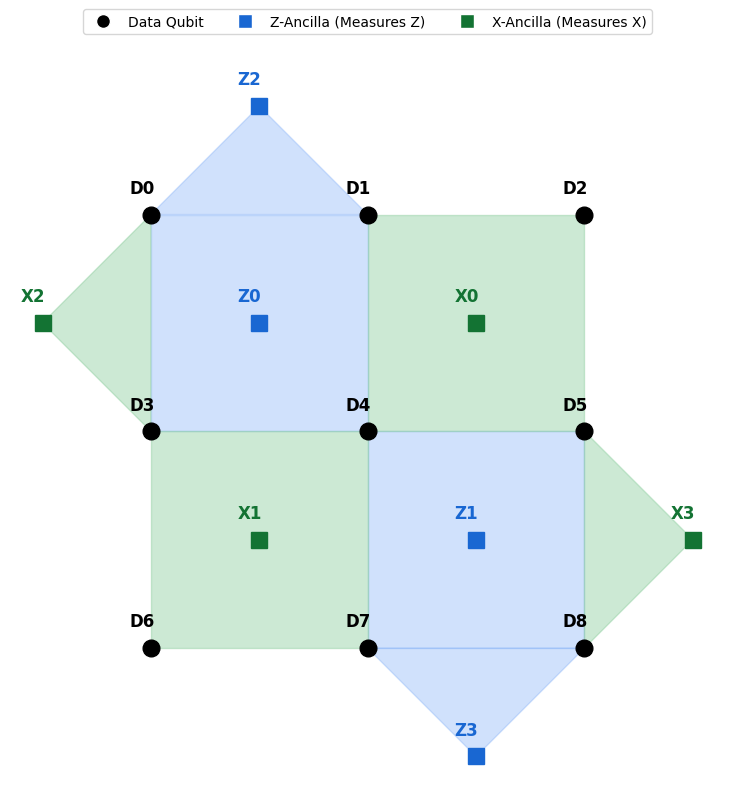

In [9]:
# coordinates for the d=3 rotated surface code
data_coords = {
    0: (0, 2), 1: (2, 2), 2: (4, 2),
    3: (0, 0), 4: (2, 0), 5: (4, 0),
    6: (0, -2), 7: (2, -2), 8: (4, -2)
}

# Z-ancillas
z_ancillas = {
    'Z0': {'coord': (1, 1), 'data': [0, 1, 4, 3]},  # Weight-4
    'Z1': {'coord': (3, -1), 'data': [4, 5, 8, 7]}, # Weight-4
    'Z2': {'coord': (1, 3), 'data': [0, 1]},        # Weight-2 (Top boundary)
    'Z3': {'coord': (3, -3), 'data': [7, 8]}        # Weight-2 (Bottom boundary)
}

# X-ancillas
x_ancillas = {
    'X0': {'coord': (3, 1), 'data': [1, 2, 5, 4]},  # Weight-4
    'X1': {'coord': (1, -1), 'data': [3, 4, 7, 6]}, # Weight-4
    'X2': {'coord': (-1, 1), 'data': [0, 3]},       # Weight-2 (Left boundary)
    'X3': {'coord': (5, -1), 'data': [5, 8]}        # Weight-2 (Right boundary)
}

fig, ax = plt.subplots(figsize=(8, 8))
ax.set_aspect('equal')

# draw stabilizer plaquettes
def draw_plaquette(ancilla_dict, color, alpha):
    for ancilla, info in ancilla_dict.items():
        poly_coords = [data_coords[d] for d in info['data']]
        
        if len(poly_coords) == 2:
            poly_coords.append(info['coord'])
            
        polygon = patches.Polygon(poly_coords, closed=True, fill=True, color=color, alpha=alpha)
        ax.add_patch(polygon)

# draw Z-checks (Blue) and X-checks (Green)
draw_plaquette(z_ancillas, color='#8AB4F8', alpha=0.4) # Light Blue
draw_plaquette(x_ancillas, color='#81C995', alpha=0.4) # Light Green

# plot data qubits
for q_id, coord in data_coords.items():
    ax.plot(coord[0], coord[1], 'ko', markersize=12, zorder=5)
    ax.text(coord[0]-0.2, coord[1]+0.2, f'D{q_id}', fontsize=12, fontweight='bold')

# plot Z-ancillas
for a_id, info in z_ancillas.items():
    coord = info['coord']
    ax.plot(coord[0], coord[1], 's', color='#1967D2', markersize=12, zorder=5)
    ax.text(coord[0]-0.2, coord[1]+0.2, a_id, color='#1967D2', fontsize=12, fontweight='bold')

# plot X-ancillas
for a_id, info in x_ancillas.items():
    coord = info['coord']
    ax.plot(coord[0], coord[1], 's', color='#137333', markersize=12, zorder=5)
    ax.text(coord[0]-0.2, coord[1]+0.2, a_id, color='#137333', fontsize=12, fontweight='bold')

data_legend = plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='k', markersize=10, label='Data Qubit')
z_legend = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#1967D2', markersize=10, label='Z-Ancilla (Measures Z)')
x_legend = plt.Line2D([0], [0], marker='s', color='w', markerfacecolor='#137333', markersize=10, label='X-Ancilla (Measures X)')
ax.legend(handles=[data_legend, z_legend, x_legend], loc='upper center', bbox_to_anchor=(0.5, 1.1), ncol=3)

ax.axis('off')
plt.tight_layout()
plt.show()

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
import pymatching
import re
import os

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [3]:
def physical_angle(logical_angle_in_pi: float, num_physical_rotations: int) -> float:
    """
    Compute the physical rotation angle needed to achieve a logical rotation of
    angle `logical_angle_in_pi` on `num_physical_rotations` physical rotations.

    Args:
        logical_angle_in_pi (float): The logical rotation angle in units of pi.
        num_physical_rotations (int): The number of physical rotations that are applied.
    Returns:
        float: The physical rotation angle in units of pi.
    """

    assert (
        num_physical_rotations % 2 == 1 and num_physical_rotations > 0
    ), "k must be a positive odd integer"
    sign = -1 if (num_physical_rotations + 1) % 4 == 0 else 1
    logical_angle_in_rad = logical_angle_in_pi * np.pi
    x = np.tan(logical_angle_in_rad / 2) ** (1 / num_physical_rotations)
    theta_phys = 2 * np.arctan(x)
    return float(sign * theta_phys / np.pi)

In [22]:
circ = tsim.Circuit.from_file("../assets/star_circuits/star_d=3.stim")
circ.diagram(height=500)

In [ ]:
circ.without_noise().diagram(type="timeslice-svg", height=1500, width=1000)

distance 3 | angle: 0.0001π | logical error rate / distance: 0.002228707226675532
distance 3 | angle: 0.0003π | logical error rate / distance: 0.002116428568452716
distance 3 | angle: 0.0008π | logical error rate / distance: 0.0021511090865378533
distance 3 | angle: 0.0022π | logical error rate / distance: 0.0023055106053487848
distance 3 | angle: 0.0060π | logical error rate / distance: 0.00198495515299923
distance 3 | angle: 0.0167π | logical error rate / distance: 0.0020989236424235713
distance 3 | angle: 0.0464π | logical error rate / distance: 0.0021656953851000157
distance 3 | angle: 0.1292π | logical error rate / distance: 0.003281219841729396
distance 3 | angle: 0.3594π | logical error rate / distance: 0.008803720817855094
distance 3 | angle: 1.0000π | logical error rate / distance: 0.0022183959979322106
distance 5 | angle: 0.0001π | logical error rate / distance: 4.0424456796361795e-05
distance 5 | angle: 0.0003π | logical error rate / distance: 1.742236160111503e-05
distance 

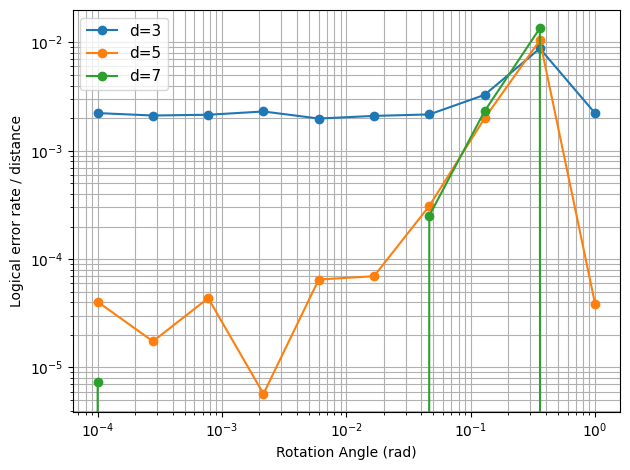

In [26]:
distances = [3, 5, 7]
theta_logspace = np.logspace(-4, 0, 10)
base_angles = ["-0.1562269946295373", "0.2616095711649016", "-0.3213254571082384"]

for d, base_angle in zip(distances, base_angles):
    logical_error_rates = []
    base_path = f"../assets/star_circuits/star_d={d}.stim"
    with open(base_path, 'r') as f:
        base_circuit_str = f.read()

    for theta in theta_logspace:
        theta_p = physical_angle(theta, num_physical_rotations=d)
        # update physical rotations and logical unrotation in the circuit
        current_circuit_str = base_circuit_str.replace(f"R_Z({base_angle})", f"R_Z({theta_p})")
        current_circuit_str = current_circuit_str.replace("R_Z(-0.01)", f"R_Z(-{theta})")

        temp_circ = f"temp_circ_{d}.stim"
        with open(temp_circ, 'w') as f:
            f.write(current_circuit_str)

        # compile circuit and sample
        circ = tsim.Circuit.from_file(temp_circ)
        sampler = circ.compile_detector_sampler()
        detectors, observables = sampler.sample(shots=100000, separate_observables=True)

        # post-select on perfect stabilizers
        # we only use the first 3*(d**2 - 1) detectors
        n_detectors = 3*(d**2 - 1)
        post_selection_mask = np.sum(detectors[:, :n_detectors], axis=1) == 0
        surviving_detectors = detectors[post_selection_mask]
        surviving_observables = observables[post_selection_mask]

        # MWPM on the remaining detectors
        dem = circ.detector_error_model(decompose_errors=False)
        matching = pymatching.Matching.from_detector_error_model(dem)
        predicted_observables = matching.decode_batch(surviving_detectors)

        # compute fidelity
        logical_errors = np.any(predicted_observables != surviving_observables, axis=1)
        logical_error_rate = np.sum(logical_errors) / len(surviving_observables)
            
        logical_error_rates.append(logical_error_rate / d)
        print(f"distance {d} | angle: {theta:.4f}π | logical error rate / distance: {logical_error_rate / d}")

    plt.plot(theta_logspace, logical_error_rates, marker='o', label=f"d={d}")
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rotation Angle (rad)')
plt.ylabel('Logical error rate / distance')
plt.grid(True, which="both")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

E0405 11:21:55.349837    1995 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %gather.38 = s32[3900013,1,4]{2,1,0} gather(%constant.648, %broadcast.695), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,4}, metadata={op_name="jit(_sample_component_jit)/jit(evaluate)/gather" stack_frame_id=274}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0405 11:21:57.261026    1985 slow_operation_alarm.cc:140] The operation took 2.911397149s
Constant folding an instruction is taking > 1s:

  %gather.38 = s32[3900013,1,4]{2,1,0} gather(%constant.648, %broadcast.695), offs

distance 3 | angle: 0.0001π | logical error rate / distance: 0.002136453076245441
distance 3 | angle: 0.0003π | logical error rate / distance: 0.002116858913428772
distance 3 | angle: 0.0008π | logical error rate / distance: 0.0020896130632434675
distance 3 | angle: 0.0022π | logical error rate / distance: 0.002064104910565138
distance 3 | angle: 0.0060π | logical error rate / distance: 0.0020327661435123596
distance 3 | angle: 0.0167π | logical error rate / distance: 0.002168579038584967
distance 3 | angle: 0.0464π | logical error rate / distance: 0.002413362267376866
distance 3 | angle: 0.1292π | logical error rate / distance: 0.003439841002904755
distance 3 | angle: 0.3594π | logical error rate / distance: 0.008935639042805822


E0405 11:22:52.905620    1995 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 2s:

  %gather.21 = s32[3900013,1,4]{2,1,0} gather(%constant.526, %broadcast.598), offset_dims={1,2}, collapsed_slice_dims={}, start_index_map={0}, index_vector_dim=1, slice_sizes={1,4}, metadata={op_name="jit(_sample_component_jit)/jit(evaluate)/gather" stack_frame_id=192}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0405 11:22:54.380280    1985 slow_operation_alarm.cc:140] The operation took 3.475716619s
Constant folding an instruction is taking > 2s:

  %gather.21 = s32[3900013,1,4]{2,1,0} gather(%constant.526, %broadcast.598), offs

distance 3 | angle: 1.0000π | logical error rate / distance: 0.002034842598940141
distance 5 | angle: 0.0001π | logical error rate / distance: 3.1073522656651084e-05
distance 5 | angle: 0.0003π | logical error rate / distance: 2.027898083636311e-05
distance 5 | angle: 0.0008π | logical error rate / distance: 3.24238444952418e-05
distance 5 | angle: 0.0022π | logical error rate / distance: 4.3599416146948987e-05
distance 5 | angle: 0.0060π | logical error rate / distance: 3.110792055515674e-05
distance 5 | angle: 0.0167π | logical error rate / distance: 7.989480517318863e-05
distance 5 | angle: 0.0464π | logical error rate / distance: 0.000275160293850427
distance 5 | angle: 0.1292π | logical error rate / distance: 0.002198942997357493
distance 5 | angle: 0.3594π | logical error rate / distance: 0.010658040350727847
distance 5 | angle: 1.0000π | logical error rate / distance: 2.3252704580201485e-05
distance 7 | angle: 0.0001π | logical error rate / distance: 0.0
distance 7 | angle: 0.00

KeyboardInterrupt: 

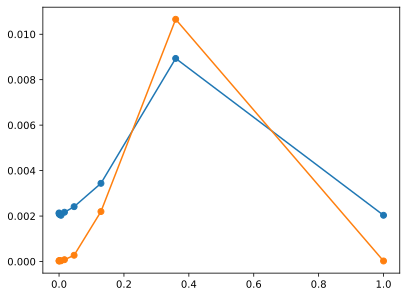

In [4]:
distances = [3, 5, 7]
theta_logspace = np.logspace(-4, 0, 10)
base_angles = ["-0.1562269946295373", "0.2616095711649016", "-0.3213254571082384"]

for d, base_angle in zip(distances, base_angles):
    logical_error_rates = []
    base_path = f"../assets/star_circuits/star_d={d}.stim"
    with open(base_path, 'r') as f:
        base_circuit_str = f.read()

    for theta in theta_logspace:
        theta_p = physical_angle(theta, num_physical_rotations=d)
        # update physical rotations and logical unrotation in the circuit
        current_circuit_str = base_circuit_str.replace(f"R_Z({base_angle})", f"R_Z({theta_p})")
        current_circuit_str = current_circuit_str.replace("R_Z(-0.01)", f"R_Z(-{theta})")

        temp_circ = f"temp_circ_{d}.stim"
        with open(temp_circ, 'w') as f:
            f.write(current_circuit_str)

        # compile circuit and sample
        circ = tsim.Circuit.from_file(temp_circ)
        sampler = circ.compile_detector_sampler()
        detectors, observables = sampler.sample(shots=300000, separate_observables=True)

        # post-select on perfect stabilizers
        # we only use the first 3*(d**2 - 1) detectors
        n_detectors = 3*(d**2 - 1)
        post_selection_mask = np.sum(detectors[:, :n_detectors], axis=1) == 0
        surviving_detectors = detectors[post_selection_mask]
        surviving_observables = observables[post_selection_mask]

        # MWPM on the remaining detectors
        dem = circ.detector_error_model(decompose_errors=False)
        matching = pymatching.Matching.from_detector_error_model(dem)
        predicted_observables = matching.decode_batch(surviving_detectors)

        # compute fidelity
        logical_errors = np.any(predicted_observables != surviving_observables, axis=1)
        logical_error_rate = np.sum(logical_errors) / len(surviving_observables)
            
        logical_error_rates.append(logical_error_rate / d)
        print(f"distance {d} | angle: {theta:.4f}π | logical error rate / distance: {logical_error_rate / d}")

    plt.plot(theta_logspace, logical_error_rates, marker='o', label=f"d={d}")
    
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Rotation Angle (rad)')
plt.ylabel('Logical error rate / distance')
plt.grid(True, which="both")
plt.legend(fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
from typing import Any

from kirin.ir import Method
from kirin.dialects.ilist import IList
from bloqade import squin, tsim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit

Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# encode the logical |0> in the Steane code
@squin.kernel
def steane_logical_zero() -> Register:
    q = squin.qalloc(7)
    
    # prepare the 3 generator qubits in superposition
    squin.h(q[0])
    squin.h(q[1])
    squin.h(q[2])
    
    # apply CNOTs mapping the [7,4] Hamming parity check matrix
    # generator 1
    squin.cx(q[0], q[4])
    squin.cx(q[0], q[5])
    squin.cx(q[0], q[6])
    
    # generator 2
    squin.cx(q[1], q[3])
    squin.cx(q[1], q[5])
    squin.cx(q[1], q[6])
    
    # generator 3
    squin.cx(q[2], q[3])
    squin.cx(q[2], q[4])
    squin.cx(q[2], q[6])
    
    return q

In [ ]:
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

show_circuit(steane_logical_zero)

In [ ]:
@squin.kernel
def t_magic_state_injection():
    """
    Injects a T-gate onto a target qubit using a T-magic state, 
    a CNOT, and a feed-forward phase correction.
    """
    # q[0] -> ancilla, q[1] -> target
    q = squin.qalloc(2)
    
    # ürepare ancilla in the |T> magic state T(H(|0>))
    squin.h(q[0])
    squin.t(q[0])

    # entangle target and ancilla
    squin.cnot(q[1], q[0])
    
    # measure the Ancilla in the computational basis
    ancilla_meas = squin.measure(q[0])
    
    # feed-forward correction
    # If the ancilla measurement is 1, the target is in the T^\dagger |\psi> state.
    # We apply an S gate (phase correction) to map it back to T |\psi>.
    if ancilla_meas:
        squin.s(q[1])
        
    return ancilla_meas

show_circuit(t_magic_state_injection)